In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Скачивание и загрузка данных
data_url = "car_evaluation.csv"
columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
data = pd.read_csv(data_url, header=None, names=columns)

In [3]:
# Обработка данных для удобства анализа
data.replace({
    "doors": {"5more": "больше пяти"},
    "persons": {"more": "больше пяти"},
    "buying": {"vhigh": "очень высокая", "high": "высокая", "med": "средняя", "low": "низкая"},
    "maint": {"vhigh": "очень высокая", "high": "высокая", "med": "средняя", "low": "низкая"},
    "lug_boot": {"small": "маленький", "med": "средний", "big": "большой"},
    "safety": {"low": "низкий", "med": "средний", "high": "высокий"},
    "class": {"unacc": "неприемлемо", "acc": "приемлемо", "good": "хорошо", "vgood": "очень хорошо"}
}, inplace=True)

/var/folders/l1/57zf0j612j31xgw8k5xt15gh0000gn/T/ipykernel_51943/1132225857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='safety', y='class', data=data, palette='Blues')


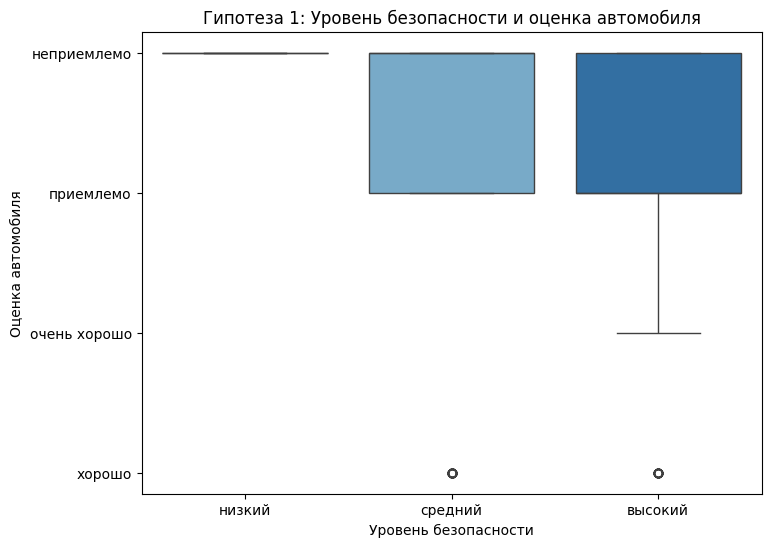

In [4]:
# Гипотеза 1: Уровень безопасности и оценка автомобиля
# Исследуется, как уровень безопасности влияет на общий класс автомобиля
plt.figure(figsize=(8, 6))
sns.boxplot(x='safety', y='class', data=data, palette='Blues')
plt.title('Гипотеза 1: Уровень безопасности и оценка автомобиля')
plt.xlabel('Уровень безопасности')
plt.ylabel('Оценка автомобиля')
plt.show()

/var/folders/l1/57zf0j612j31xgw8k5xt15gh0000gn/T/ipykernel_51943/2225950083.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='maint', y='class', data=data, palette='Reds')


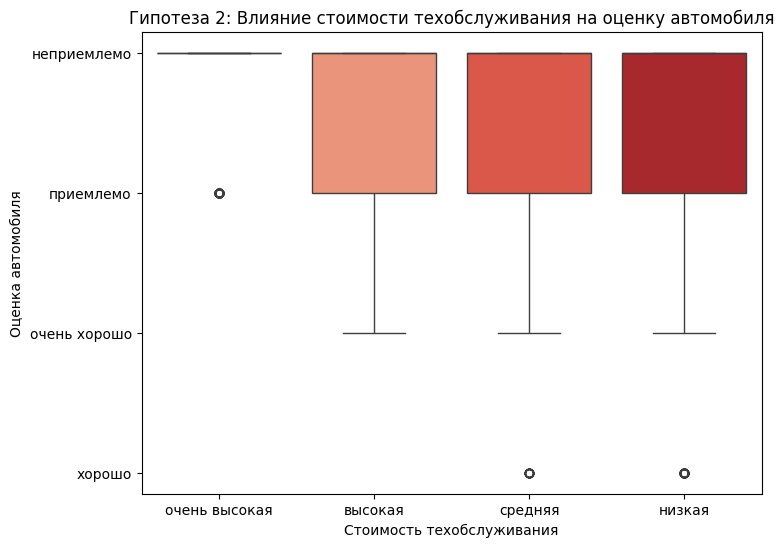

In [5]:
# Гипотеза 2: Влияние стоимости техобслуживания на оценку автомобиля
# Анализируется, как стоимость обслуживания влияет на итоговую оценку качества автомобиля
plt.figure(figsize=(8, 6))
sns.boxplot(x='maint', y='class', data=data, palette='Reds')
plt.title('Гипотеза 2: Влияние стоимости техобслуживания на оценку автомобиля')
plt.xlabel('Стоимость техобслуживания')
plt.ylabel('Оценка автомобиля')
plt.show()

/var/folders/l1/57zf0j612j31xgw8k5xt15gh0000gn/T/ipykernel_51943/2860923650.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='buying', y='class', data=data, palette='Greens')


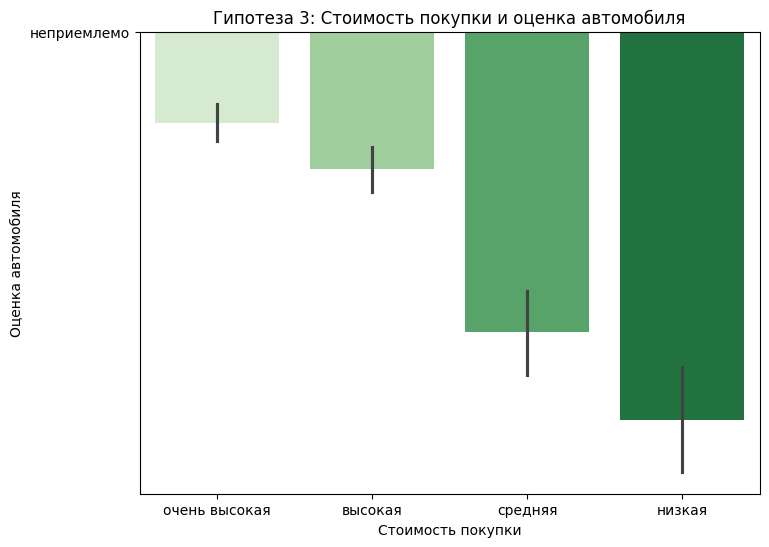

In [6]:
# Гипотеза 3: Стоимость покупки и оценка автомобиля
# Исследуется, влияет ли цена покупки на итоговую оценку качества автомобиля
plt.figure(figsize=(8, 6))
sns.barplot(x='buying', y='class', data=data, palette='Greens')
plt.title('Гипотеза 3: Стоимость покупки и оценка автомобиля')
plt.xlabel('Стоимость покупки')
plt.ylabel('Оценка автомобиля')
plt.show()

/var/folders/l1/57zf0j612j31xgw8k5xt15gh0000gn/T/ipykernel_51943/2633861593.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='persons', y='class', data=data, ci=None, palette='Oranges')
/var/folders/l1/57zf0j612j31xgw8k5xt15gh0000gn/T/ipykernel_51943/2633861593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='persons', y='class', data=data, ci=None, palette='Oranges')


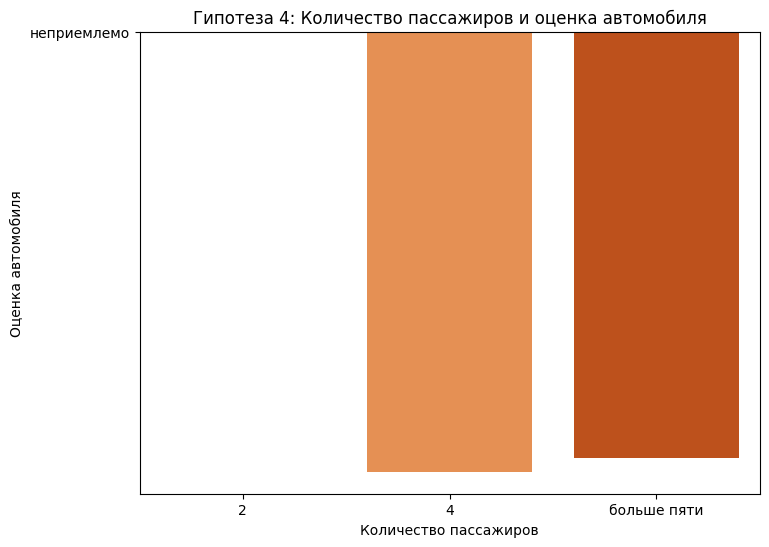

In [7]:
# Гипотеза 4: Количество пассажиров и оценка
# Анализируется связь между количеством пассажиров, которое может вместить автомобиль, и его оценкой
plt.figure(figsize=(8, 6))
sns.barplot(x='persons', y='class', data=data, ci=None, palette='Oranges')
plt.title('Гипотеза 4: Количество пассажиров и оценка автомобиля')
plt.xlabel('Количество пассажиров')
plt.ylabel('Оценка автомобиля')
plt.show()

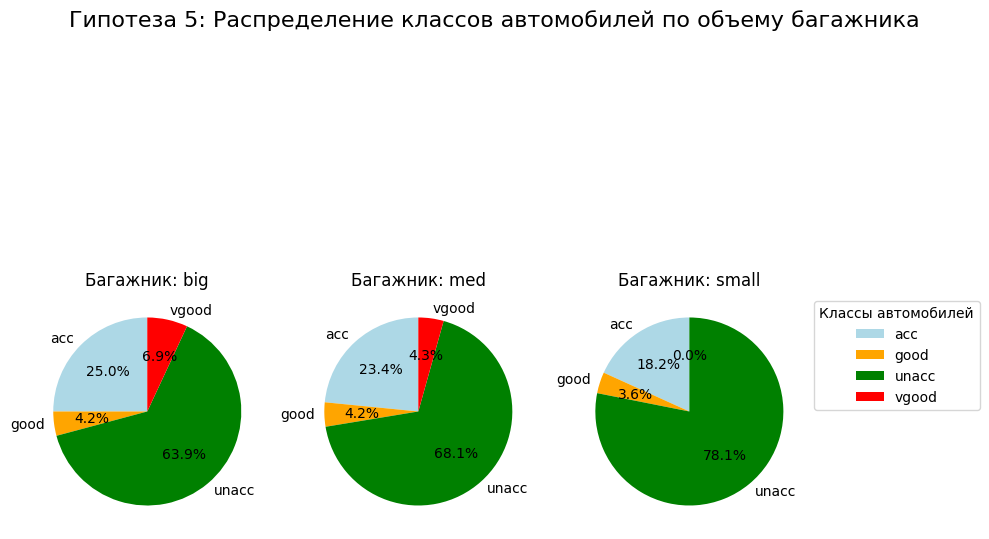

In [8]:

data = pd.read_csv(data_url, header=None, names=columns)

# Группируем данные по размеру багажника и классу автомобиля
lug_boot_class = data.groupby(['lug_boot', 'class']).size().unstack(fill_value=0)

# Настроим цветовую палитру
colors = ['lightblue', 'orange', 'green', 'red']

# Строим круговые диаграммы для каждого размера багажника
plt.figure(figsize=(10, 8))

# Для каждого размера багажника строим диаграмму
for i, lug_boot in enumerate(lug_boot_class.index):
    plt.subplot(1, 3, i+1)  # 1 строка, 3 колонки, i+1 номер диаграммы
    lug_boot_class.loc[lug_boot].plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f"Багажник: {lug_boot}")
    plt.ylabel('')  # Убираем название оси Y

# Добавляем общую легенду для всех графиков
plt.legend(lug_boot_class.columns, title="Классы автомобилей", loc='upper left', bbox_to_anchor=(1, 1))

# Добавляем общий заголовок
plt.suptitle('Гипотеза 5: Распределение классов автомобилей по объему багажника', fontsize=16)
plt.tight_layout()

# Отображаем график
plt.show()


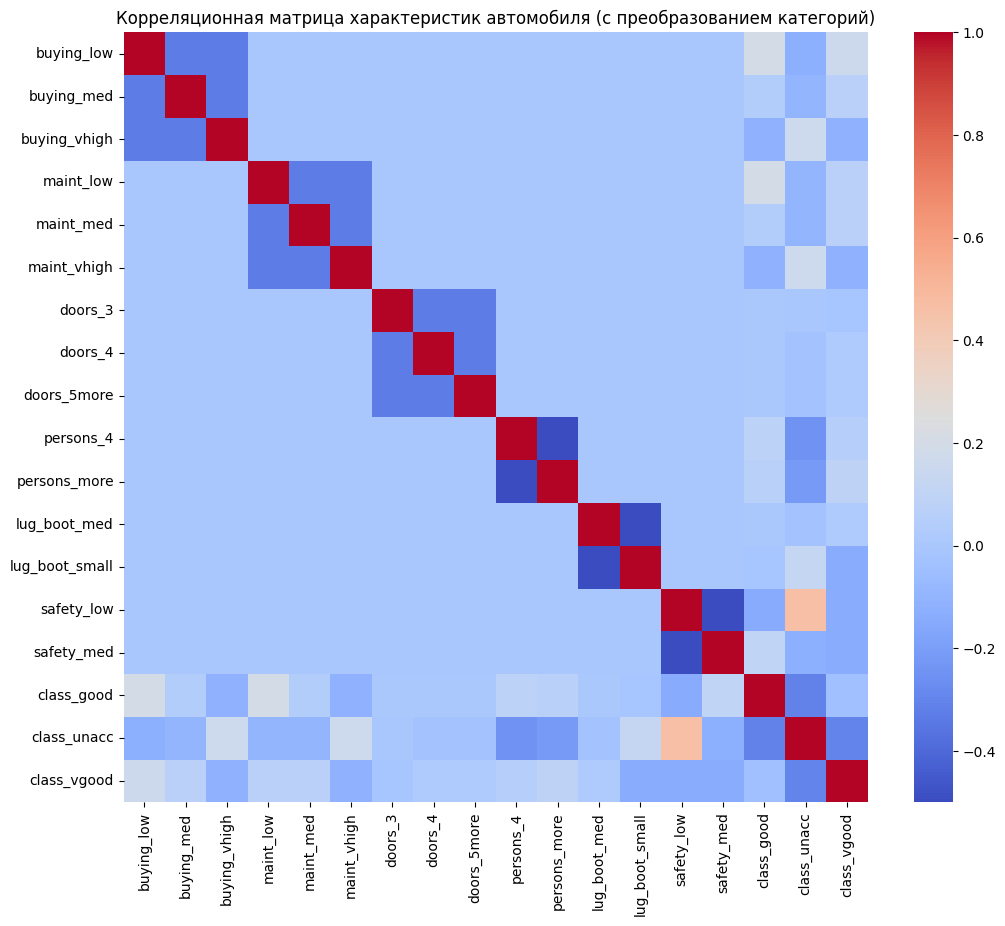

In [9]:
# Преобразование категориальных данных в числовые
correlation_data = pd.get_dummies(data, columns=["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"], drop_first=True)

# Построение корреляционной матрицы
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_data.corr(), annot=False, cmap="coolwarm", fmt=".2f")
plt.title('Корреляционная матрица характеристик автомобиля (с преобразованием категорий)')
plt.show()